# Examples

## Setup

In [1]:
from ase.build import bulk
import tricor as tc
import matplotlib.pyplot as plt

atoms = bulk('Si', 'diamond', a=5.431)
shell_target = tc.CoordinationShellTarget.from_atoms(
    atoms,
    phi_num_bins=90,
)

## Disorder spectrum

Generate all six regimes and compare their g3 distributions:

In [2]:
cases = [
    ("liquid",          0.86, 80,  dict(grain_size=None, bond_weight=1.0, angle_weight=0.12)),
    ("amorphous",       0.88, 150, dict(grain_size=4.0, bond_weight=1.5, angle_weight=0.3)),
    ("SRO",             0.90, 150, dict(grain_size=8.0, bond_weight=2.0, angle_weight=1.0)),
    ("MRO",             0.92, 150, dict(grain_size=12.0, crystalline_fraction=0.5, bond_weight=2.0, angle_weight=0.6)),
    ("mixed",           0.94, 150, dict(grain_size=18.0, crystalline_fraction=0.5, bond_weight=2.5, angle_weight=1.0)),
    ("nanocrystalline", 0.96, 150, dict(grain_size=25.0, bond_weight=3.0, angle_weight=1.5)),
]

cells = {}
for name, density, steps, kw in cases:
    print(f"Generating {name}...")
    cell = tc.Supercell.from_atoms(
        atoms,
        cell_dim_angstroms=(30, 30, 30),
        r_max=10,
        r_step=0.2,
        phi_num_bins=90,
        relative_density=density,
        rng_seed=42,
    )
    cell.generate(
        shell_target,
        num_steps=steps,
        show_progress=False,
        **kw,
    )
    cell.measure_g3(show_progress=False)
    cells[name] = cell
print("Done.")

Generating liquid...


Generating amorphous...


Generating SRO...


Generating MRO...


Generating mixed...


Generating nanocrystalline...


Done.


### Pair correlation profiles

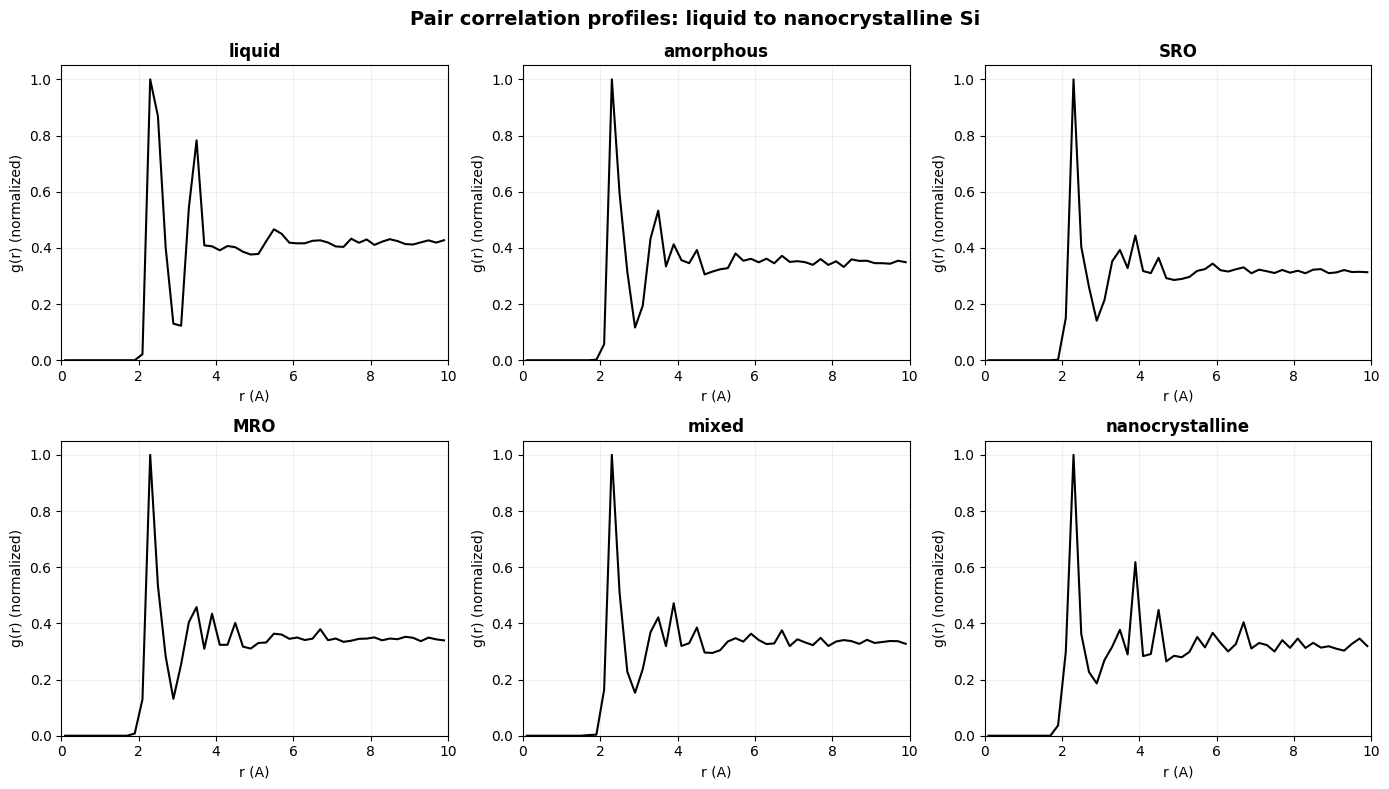

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (name, cell) in zip(axes.ravel(), cells.items()):
    dist = cell.current_distribution
    g3 = dist.g3[0].astype(float)
    r = dist.r

    # Sum over phi and r02 to get the pair profile
    pair = g3.sum(axis=(1, 2))
    # Normalize by r^2 shell volume
    r_safe = r.copy()
    r_safe[r_safe < 1e-6] = 1e-6
    pair_norm = pair / (r_safe ** 2)
    pair_norm /= max(pair_norm.max(), 1e-10)

    ax.plot(r, pair_norm, 'k-', lw=1.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('r (A)')
    ax.set_ylabel('g(r) (normalized)')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, None)
    ax.grid(alpha=0.2)

fig.suptitle(
    'Pair correlation profiles: liquid to nanocrystalline Si',
    fontsize=14,
    fontweight='bold',
)
fig.tight_layout()
plt.show()

### Shell relaxation convergence

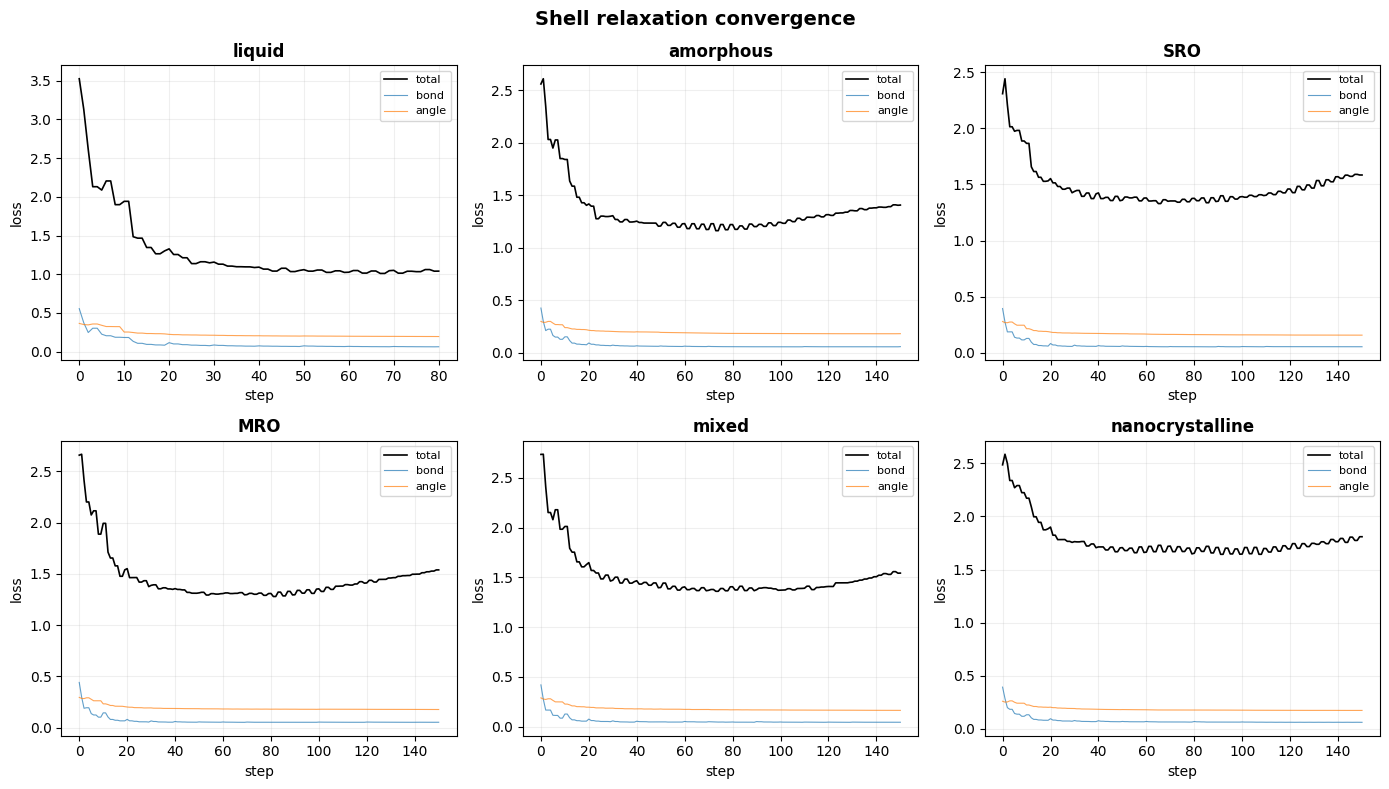

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (name, cell) in zip(axes.ravel(), cells.items()):
    hist = cell.shell_relax_history
    if hist is not None:
        ax.plot(hist["step"], hist["loss"], 'k-', lw=1.2, label='total')
        ax.plot(hist["step"], hist["bond_loss"], '-', lw=0.8, alpha=0.7, label='bond')
        ax.plot(hist["step"], hist["angle_loss"], '-', lw=0.8, alpha=0.7, label='angle')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('step')
    ax.set_ylabel('loss')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

fig.suptitle(
    'Shell relaxation convergence',
    fontsize=14,
    fontweight='bold',
)
fig.tight_layout()
plt.show()

## SiC binary example

In [5]:
atoms_sic = bulk('SiC', 'zincblende', a=4.36)
shell_target_sic = tc.CoordinationShellTarget.from_atoms(
    atoms_sic,
    phi_num_bins=90,
)

print(f"Species: {shell_target_sic.species_labels}")
print(f"Coordination targets:\n{shell_target_sic.coordination_target}")
print(f"Pair peaks:\n{shell_target_sic.pair_peak}")

Species: ('C', 'Si')
Coordination targets:
[[12.  4.]
 [ 4. 12.]]
Pair peaks:
[[3.08298557 1.88793538]
 [1.88793538 3.08298557]]


In [6]:
cell_sic = tc.Supercell.from_atoms(
    atoms_sic,
    cell_dim_angstroms=(30, 30, 30),
    r_max=10,
    r_step=0.2,
    phi_num_bins=90,
    relative_density=0.92,
    rng_seed=42,
)
cell_sic.generate(
    shell_target_sic,
    grain_size=12.0,
    crystalline_fraction=0.5,
    bond_weight=2.0,
    angle_weight=0.6,
    show_progress=False,
)
cell_sic.measure_g3(show_progress=False)

# Show triplet channel counts
g3 = cell_sic.current_distribution.g3
labels = cell_sic.current_distribution.pair_labels
for i, label in enumerate(labels):
    total = float(g3[i].sum())
    print(f"  {label}: {total:.0f} counts")

  C-C-C: 28898016 counts
  C-C-Si: 58394030 counts
  Si-C-Si: 29281686 counts
  C-Si-C: 29299822 counts
  C-Si-Si: 58233822 counts
  Si-Si-Si: 28722468 counts


### SiC pair profiles by triplet type

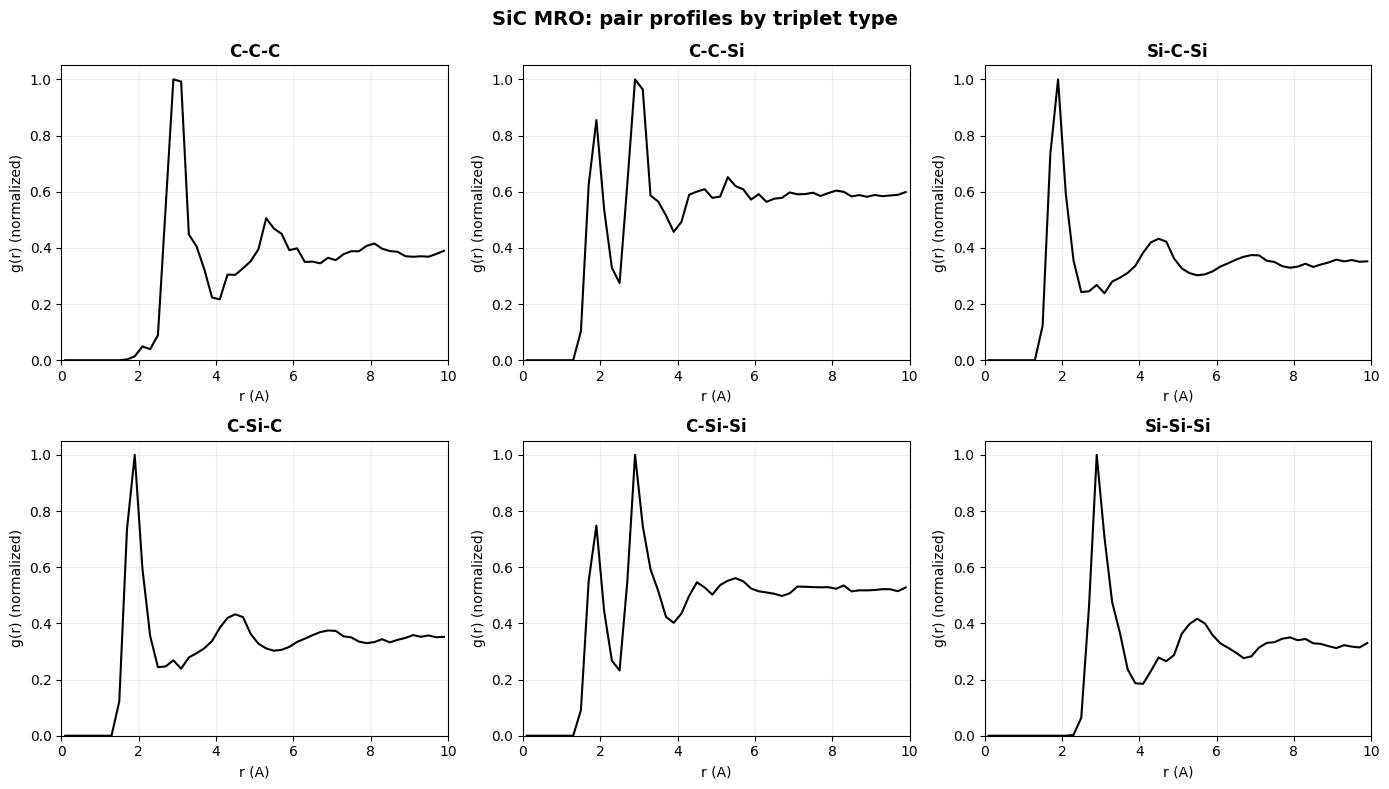

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

dist = cell_sic.current_distribution
r = dist.r

for ax, (i, label) in zip(axes.ravel(), enumerate(dist.pair_labels)):
    g3_ch = dist.g3[i].astype(float)
    pair = g3_ch.sum(axis=(1, 2))
    r_safe = r.copy()
    r_safe[r_safe < 1e-6] = 1e-6
    pair_norm = pair / (r_safe ** 2)
    pair_norm /= max(pair_norm.max(), 1e-10)

    ax.plot(r, pair_norm, 'k-', lw=1.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('r (A)')
    ax.set_ylabel('g(r) (normalized)')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, None)
    ax.grid(alpha=0.2)

# Hide unused axes
for ax in axes.ravel()[len(dist.pair_labels):]:
    ax.set_visible(False)

fig.suptitle(
    'SiC MRO: pair profiles by triplet type',
    fontsize=14,
    fontweight='bold',
)
fig.tight_layout()
plt.show()